# Experiment 08 — Presentation Charts

Visualization of the quantization diagnosis findings across 6 datasets:
- **Factual QA**: DROP, MS MARCO
- **Reasoning**: GSM8K, HotpotQA, ROPES, RACE-high

Charts generated:
1. **Figure 1**: NLL improvement by perturbation type (all 6 datasets)
2. **Figure 2**: Hypothesis verdict grid (6 datasets × 5 findings)
3. **Figure 3**: H_C — normalization alone accounts for the benefit
4. **Figure 4**: H_E — keys and values contribute equally
5. **Figure 5**: Prefix + quantization stack with partial overlap
6. **Figure 6**: Benefit increases with task difficulty
7. **Figure 7**: Mechanism decomposition (normalization vs rounding)
8. **Figure 8**: Prefix shielding — conditioned caches need less quantization correction

In [1]:
# Cell 2: Setup and load all results
import os
os.umask(0o000)
import json
import numpy as np
from pathlib import Path
from scipy import stats

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

RESULTS_DIR = Path("../../../results/decoder_only/exp08")
CHARTS_DIR = RESULTS_DIR / "charts"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

# Load both result files
with open(RESULTS_DIR / "results.json") as f:
    res_main = json.load(f)
with open(RESULTS_DIR / "results_reasoning.json") as f:
    res_reason = json.load(f)

# Merge per-sample results into unified dict
per_sample = {}
for ds in res_main.get('per_sample_results', {}):
    per_sample[ds] = res_main['per_sample_results'][ds]
for ds in res_reason.get('per_sample_results', {}):
    per_sample[ds] = res_reason['per_sample_results'][ds]

# Merge hypothesis results
hyp_results = {}
for ds in res_main.get('hypothesis_results', {}):
    hyp_results[ds] = res_main['hypothesis_results'][ds]
for ds in res_reason.get('hypothesis_results', {}):
    hyp_results[ds] = res_reason['hypothesis_results'][ds]

# Dataset display names and ordering
DS_ORDER = ['drop', 'ms_marco', 'gsm8k', 'hotpotqa', 'ropes', 'race_high']
DS_LABELS = {
    'drop': 'DROP', 'ms_marco': 'MS MARCO',
    'gsm8k': 'GSM8K', 'hotpotqa': 'HotpotQA',
    'ropes': 'ROPES', 'race_high': 'RACE-high',
}
DS_COLORS = {
    'drop': '#d62728', 'ms_marco': '#ff7f0e',
    'gsm8k': '#2ca02c', 'hotpotqa': '#1f77b4',
    'ropes': '#9467bd', 'race_high': '#8c564b',
}
DS_CATEGORIES = {
    'drop': 'Factual', 'ms_marco': 'Factual',
    'gsm8k': 'Reasoning', 'hotpotqa': 'Reasoning',
    'ropes': 'Reasoning', 'race_high': 'Reasoning',
}

CONDITIONING = ['bare', 'comprehend_64']
PERTURBATIONS = ['bf16', 'int8', 'int4', 'int16', 'gaussian_matched',
                 'clip_2sigma', 'clip_3sigma', 'K_only_int8', 'V_only_int8',
                 'per_channel_int8']
PERT_ONLY = [p for p in PERTURBATIONS if p != 'bf16']

# Helper: cohens_d for paired differences
def cohens_d(diffs):
    return np.mean(diffs) / (np.std(diffs, ddof=1) + 1e-10)

# Build per-dataset NLL arrays
nll_arrays = {}
for ds in DS_ORDER:
    if ds not in per_sample:
        continue
    results = per_sample[ds]
    nll_arrays[ds] = {}
    for cond in CONDITIONING:
        for pert in PERTURBATIONS:
            key = f'nll_{cond}_{pert}'
            nll_arrays[ds][(cond, pert)] = np.array([r[key] for r in results])
    nll_arrays[ds]['single_pass'] = np.array([r['nll_single_pass'] for r in results])

available_ds = [ds for ds in DS_ORDER if ds in nll_arrays]
print(f"Loaded {len(available_ds)} datasets: {available_ds}")
for ds in available_ds:
    n = len(per_sample[ds])
    print(f"  {DS_LABELS[ds]}: {n} samples")


Loaded 6 datasets: ['drop', 'ms_marco', 'gsm8k', 'hotpotqa', 'ropes', 'race_high']
  DROP: 160 samples
  MS MARCO: 160 samples
  GSM8K: 200 samples
  HotpotQA: 160 samples
  ROPES: 200 samples
  RACE-high: 160 samples


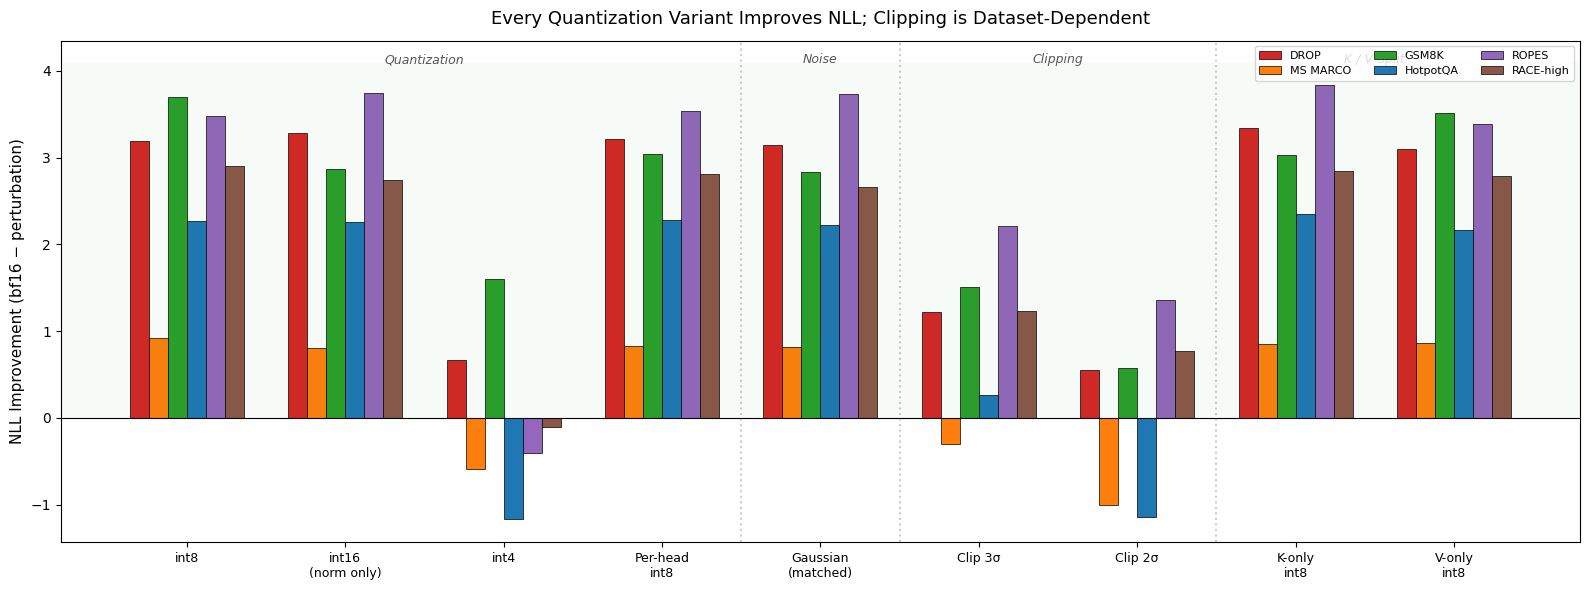

Saved: ../../../results/decoder_only/exp08/charts/fig1_nll_improvement_by_perturbation.png


In [2]:
# Cell 3: Figure 1 — NLL improvement by perturbation (bare conditioning)
# POSITIVE = BETTER. Grouped by perturbation category.

# Logical grouping of perturbations
pert_groups = [
    ('Quantization', ['int8', 'int16', 'int4', 'per_channel_int8']),
    ('Noise', ['gaussian_matched']),
    ('Clipping', ['clip_3sigma', 'clip_2sigma']),
    ('K / V Split', ['K_only_int8', 'V_only_int8']),
]
flat_perts = [p for _, perts in pert_groups for p in perts]
group_labels = {
    'int8': 'int8', 'int16': 'int16\n(norm only)', 'int4': 'int4',
    'per_channel_int8': 'Per-head\nint8',
    'gaussian_matched': 'Gaussian\n(matched)',
    'clip_3sigma': 'Clip 3\u03c3', 'clip_2sigma': 'Clip 2\u03c3',
    'K_only_int8': 'K-only\nint8', 'V_only_int8': 'V-only\nint8',
}

fig, ax = plt.subplots(figsize=(16, 6))

n_ds = len(available_ds)
n_pert = len(flat_perts)
width = 0.12
x = np.arange(n_pert)

for i, ds in enumerate(available_ds):
    bf16 = nll_arrays[ds][('bare', 'bf16')]
    improvements = []
    for pert in flat_perts:
        arr = nll_arrays[ds][('bare', pert)]
        improvements.append((bf16 - arr).mean())  # FLIPPED: positive = better
    offset = (i - n_ds / 2 + 0.5) * width
    ax.bar(x + offset, improvements, width, label=DS_LABELS[ds],
           color=DS_COLORS[ds], edgecolor='black', linewidth=0.5)

ax.axhline(y=0, color='black', linewidth=0.8)

# Add group separators and labels
cumulative = 0
for gname, perts in pert_groups:
    if cumulative > 0:
        ax.axvline(x=cumulative - 0.5, color='gray', linestyle=':', alpha=0.4)
    mid = cumulative + len(perts) / 2 - 0.5
    ax.text(mid, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 3.5,
            gname, ha='center', fontsize=9, color='#555555', style='italic')
    cumulative += len(perts)

ax.set_xticks(x)
ax.set_xticklabels([group_labels[p] for p in flat_perts], fontsize=9)
ax.set_ylabel('NLL Improvement (bf16 \u2212 perturbation)', fontsize=11)
ax.set_title('Every Quantization Variant Improves NLL; Clipping is Dataset-Dependent',
             fontsize=13, pad=12)
ax.legend(fontsize=8, ncol=3, loc='upper right')

# Shade the positive region lightly
ax.axhspan(0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 4, alpha=0.03, color='green')

plt.tight_layout()
plt.savefig(CHARTS_DIR / 'fig1_nll_improvement_by_perturbation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {CHARTS_DIR / 'fig1_nll_improvement_by_perturbation.png'}")


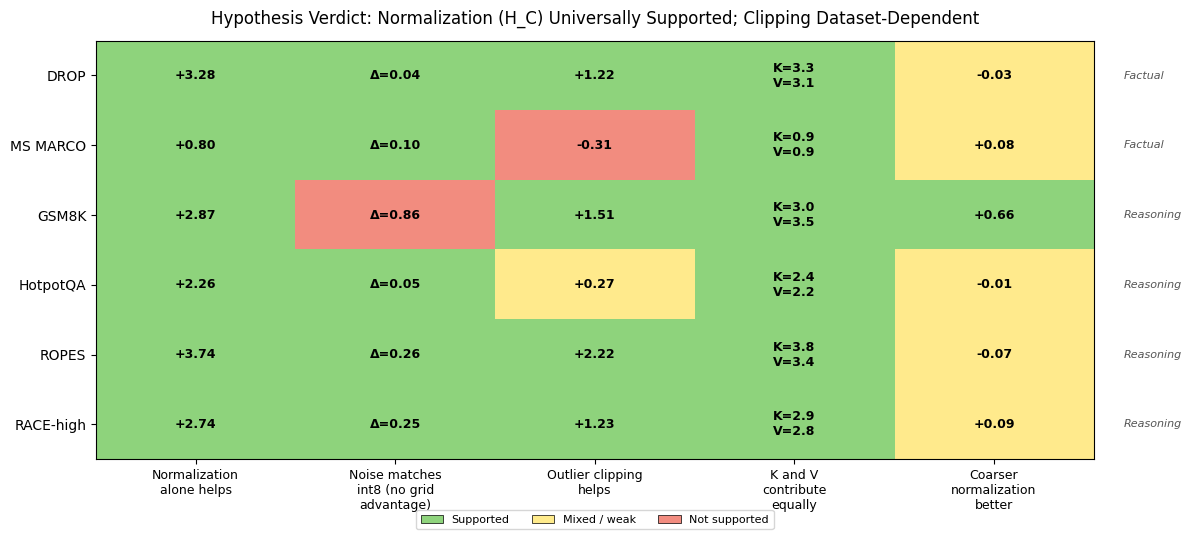

Saved: ../../../results/decoder_only/exp08/charts/fig2_hypothesis_verdict.png


In [3]:
# Cell 4: Figure 2 — Hypothesis verdict grid
# Each cell: green = supported, red = not supported, yellow = mixed.
# All values oriented so the reader can see the verdict from color alone.

findings = [
    'Normalization\nalone helps',
    'Noise matches\nint8 (no grid\nadvantage)',
    'Outlier clipping\nhelps',
    'K and V\ncontribute\nequally',
    'Coarser\nnormalization\nbetter',
]

fig, ax = plt.subplots(figsize=(12, 5.5))

n_ds = len(available_ds)
n_find = len(findings)

# Build verdict matrix: 1 = supported, 0 = inconclusive, -1 = not supported
verdict = np.zeros((n_ds, n_find))
labels = [['' for _ in range(n_find)] for _ in range(n_ds)]

for i, ds in enumerate(available_ds):
    h = hyp_results[ds]
    bf16 = nll_arrays[ds][('bare', 'bf16')]

    # Col 0: Normalization alone helps (H_C)
    # Metric: mean NLL improvement from int16 (positive = helps)
    int16_imp = (bf16 - nll_arrays[ds][('bare', 'int16')]).mean()
    labels[i][0] = f"+{int16_imp:.2f}" if int16_imp > 0 else f"{int16_imp:.2f}"
    verdict[i, 0] = 1 if int16_imp > 0.3 else (0 if int16_imp > 0 else -1)

    # Col 1: Noise matches int8 — no grid advantage (H_A)
    # Metric: |int8_imp - gaussian_imp| (small = matched = H_A supported)
    int8_imp = (bf16 - nll_arrays[ds][('bare', 'int8')]).mean()
    gauss_imp = (bf16 - nll_arrays[ds][('bare', 'gaussian_matched')]).mean()
    gap = abs(int8_imp - gauss_imp)
    labels[i][1] = f"\u0394={gap:.2f}"
    verdict[i, 1] = 1 if gap < 0.3 else (0 if gap < 0.8 else -1)

    # Col 2: Outlier clipping helps (H_B)
    # Metric: mean NLL improvement from clip_3sigma (positive = helps)
    clip3_imp = (bf16 - nll_arrays[ds][('bare', 'clip_3sigma')]).mean()
    labels[i][2] = f"+{clip3_imp:.2f}" if clip3_imp > 0 else f"{clip3_imp:.2f}"
    verdict[i, 2] = 1 if clip3_imp > 0.3 else (0 if clip3_imp > -0.3 else -1)

    # Col 3: K and V contribute equally (H_E)
    # Metric: |K_imp - V_imp| / avg(K_imp, V_imp) — small = balanced
    k_imp = (bf16 - nll_arrays[ds][('bare', 'K_only_int8')]).mean()
    v_imp = (bf16 - nll_arrays[ds][('bare', 'V_only_int8')]).mean()
    avg_kv = (abs(k_imp) + abs(v_imp)) / 2
    kv_ratio = abs(k_imp - v_imp) / (avg_kv + 1e-10)
    labels[i][3] = f"K={k_imp:.1f}\nV={v_imp:.1f}"
    verdict[i, 3] = 1 if kv_ratio < 0.15 else (0 if kv_ratio < 0.3 else -1)

    # Col 4: Coarser normalization better (supports H_C)
    # Metric: per-tensor improvement - per-head improvement (positive = per-tensor better)
    pch_imp = (bf16 - nll_arrays[ds][('bare', 'per_channel_int8')]).mean()
    advantage = int8_imp - pch_imp  # positive = per-tensor (coarser) is better
    labels[i][4] = f"+{advantage:.2f}" if advantage > 0 else f"{advantage:.2f}"
    verdict[i, 4] = 1 if advantage > 0.1 else (0 if advantage > -0.1 else -1)

# Color map: -1=red, 0=yellow, 1=green
colors_rgb = np.zeros((n_ds, n_find, 3))
for i in range(n_ds):
    for j in range(n_find):
        v = verdict[i, j]
        if v == 1:
            colors_rgb[i, j] = [0.56, 0.83, 0.49]   # green
        elif v == 0:
            colors_rgb[i, j] = [1.0, 0.92, 0.55]    # yellow
        else:
            colors_rgb[i, j] = [0.95, 0.55, 0.50]    # red

ax.imshow(colors_rgb, aspect='auto')

# Cell text
for i in range(n_ds):
    for j in range(n_find):
        ax.text(j, i, labels[i][j], ha='center', va='center',
                fontsize=9, fontweight='bold')

ax.set_xticks(range(n_find))
ax.set_xticklabels(findings, fontsize=9, ha='center')
ax.set_yticks(range(n_ds))
ax.set_yticklabels([DS_LABELS[ds] for ds in available_ds], fontsize=10)

# Category labels on right
for i, ds in enumerate(available_ds):
    ax.text(n_find - 0.5 + 0.15, i, DS_CATEGORIES[ds], ha='left', va='center',
            fontsize=8, color='#555555', style='italic')

# Legend
legend_patches = [
    mpatches.Patch(facecolor=[0.56, 0.83, 0.49], edgecolor='black', linewidth=0.5, label='Supported'),
    mpatches.Patch(facecolor=[1.0, 0.92, 0.55], edgecolor='black', linewidth=0.5, label='Mixed / weak'),
    mpatches.Patch(facecolor=[0.95, 0.55, 0.50], edgecolor='black', linewidth=0.5, label='Not supported'),
]
ax.legend(handles=legend_patches, fontsize=8, loc='lower center',
          bbox_to_anchor=(0.5, -0.18), ncol=3)

ax.set_title('Hypothesis Verdict: Normalization (H_C) Universally Supported; Clipping Dataset-Dependent',
             fontsize=12, pad=12)

plt.tight_layout()
plt.savefig(CHARTS_DIR / 'fig2_hypothesis_verdict.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {CHARTS_DIR / 'fig2_hypothesis_verdict.png'}")


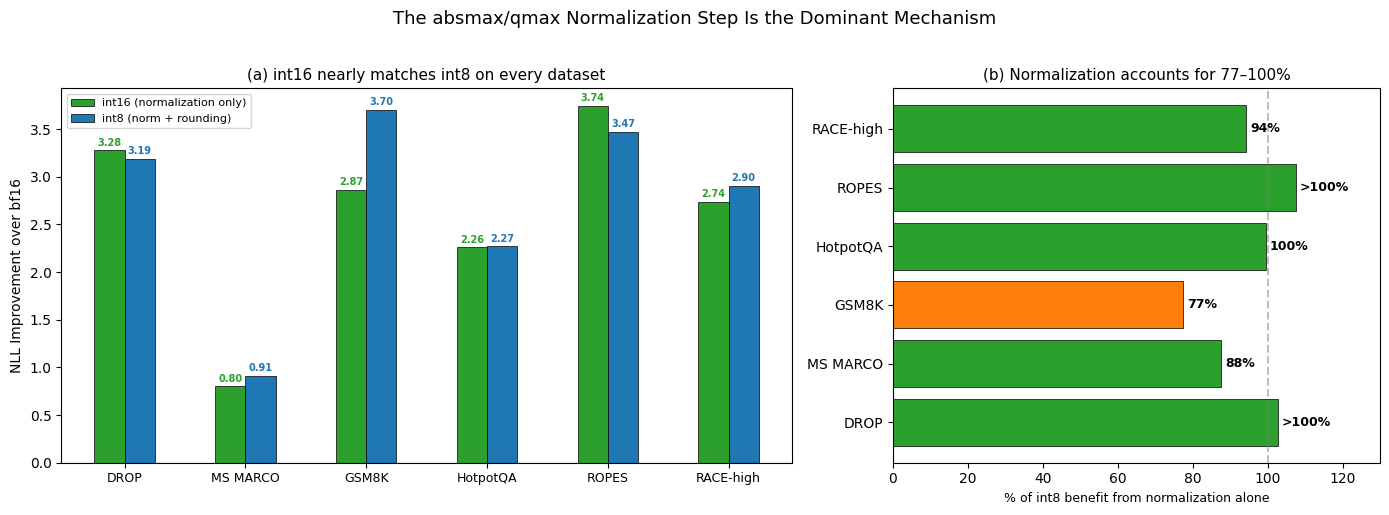

Saved: ../../../results/decoder_only/exp08/charts/fig3_normalization_mechanism.png


In [4]:
# Cell 5: Figure 3 — Normalization alone accounts for the benefit
# Panel A: NLL improvement from bf16 baseline (positive = better)
# Panel B: int16 captures nearly all of the int8 benefit

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [3, 2]})

# --- Panel A: NLL Improvement over bf16 ---
ax = axes[0]
x = np.arange(len(available_ds))
width = 0.25

int16_imp = [(nll_arrays[ds][('bare', 'bf16')] - nll_arrays[ds][('bare', 'int16')]).mean()
             for ds in available_ds]
int8_imp = [(nll_arrays[ds][('bare', 'bf16')] - nll_arrays[ds][('bare', 'int8')]).mean()
            for ds in available_ds]

ax.bar(x - width/2, int16_imp, width, label='int16 (normalization only)',
       color='#2ca02c', edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, int8_imp, width, label='int8 (norm + rounding)',
       color='#1f77b4', edgecolor='black', linewidth=0.5)

# Value labels above bars
for i in range(len(available_ds)):
    ax.text(i - width/2, int16_imp[i] + 0.05, f"{int16_imp[i]:.2f}",
            ha='center', fontsize=7, color='#2ca02c', fontweight='bold')
    ax.text(i + width/2, int8_imp[i] + 0.05, f"{int8_imp[i]:.2f}",
            ha='center', fontsize=7, color='#1f77b4', fontweight='bold')

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([DS_LABELS[ds] for ds in available_ds], fontsize=9)
ax.set_ylabel('NLL Improvement over bf16', fontsize=10)
ax.set_title('(a) int16 nearly matches int8 on every dataset', fontsize=11)
ax.legend(fontsize=8, loc='upper left')

# --- Panel B: Percentage of int8 benefit explained by normalization ---
ax = axes[1]
pct_norm = []
for i, ds in enumerate(available_ds):
    pct = int16_imp[i] / (int8_imp[i] + 1e-10) * 100
    pct = min(pct, 120)  # cap for display (int16 can exceed int8)
    pct_norm.append(pct)

colors = ['#2ca02c' if p >= 80 else '#ff7f0e' if p >= 50 else '#d62728' for p in pct_norm]
bars = ax.barh(range(len(available_ds)), pct_norm,
               color=colors, edgecolor='black', linewidth=0.5)

for i, pct in enumerate(pct_norm):
    label = f"{pct:.0f}%" if pct <= 100 else f">{100:.0f}%"
    ax.text(pct + 1, i, label, va='center', fontsize=9, fontweight='bold')

ax.axvline(x=100, color='gray', linestyle='--', alpha=0.5)
ax.set_yticks(range(len(available_ds)))
ax.set_yticklabels([DS_LABELS[ds] for ds in available_ds], fontsize=10)
ax.set_xlabel('% of int8 benefit from normalization alone', fontsize=9)
ax.set_title('(b) Normalization accounts for 77\u2013100%', fontsize=11)
ax.set_xlim(0, 130)

plt.suptitle('The absmax/qmax Normalization Step Is the Dominant Mechanism',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'fig3_normalization_mechanism.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {CHARTS_DIR / 'fig3_normalization_mechanism.png'}")


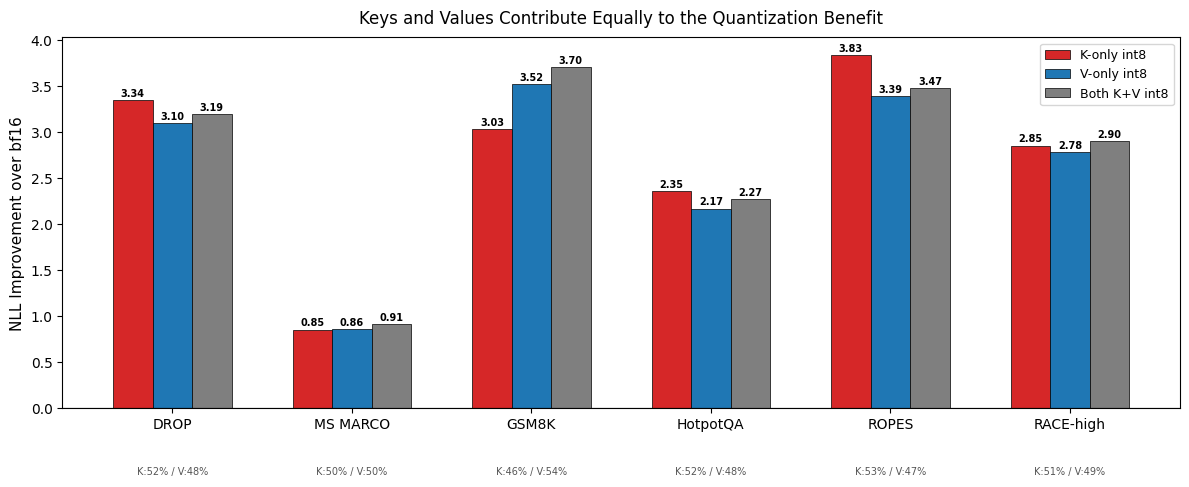

Saved: ../../../results/decoder_only/exp08/charts/fig4_k_vs_v_decomposition.png


In [5]:
# Cell 6: Figure 4 — K and V contribute equally (positive = improvement)

fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(available_ds))
width = 0.22

k_imps = []
v_imps = []
both_imps = []
for ds in available_ds:
    bf16 = nll_arrays[ds][('bare', 'bf16')]
    k_imps.append((bf16 - nll_arrays[ds][('bare', 'K_only_int8')]).mean())
    v_imps.append((bf16 - nll_arrays[ds][('bare', 'V_only_int8')]).mean())
    both_imps.append((bf16 - nll_arrays[ds][('bare', 'int8')]).mean())

ax.bar(x - width, k_imps, width, label='K-only int8',
       color='#d62728', edgecolor='black', linewidth=0.5)
ax.bar(x, v_imps, width, label='V-only int8',
       color='#1f77b4', edgecolor='black', linewidth=0.5)
ax.bar(x + width, both_imps, width, label='Both K+V int8',
       color='#7f7f7f', edgecolor='black', linewidth=0.5)

# Value labels above bars
for i in range(len(available_ds)):
    for vals, off in [(k_imps, -width), (v_imps, 0), (both_imps, width)]:
        ax.text(i + off, vals[i] + 0.04, f"{vals[i]:.2f}",
                ha='center', fontsize=7, fontweight='bold')

# K/V balance annotation below x-axis
for i, ds in enumerate(available_ds):
    k, v = k_imps[i], v_imps[i]
    pct_k = k / (k + v + 1e-10) * 100
    ax.text(i, -0.18, f"K:{pct_k:.0f}% / V:{100-pct_k:.0f}%",
            ha='center', fontsize=7, color='#555555',
            transform=ax.get_xaxis_transform())

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([DS_LABELS[ds] for ds in available_ds], fontsize=10)
ax.set_ylabel('NLL Improvement over bf16', fontsize=11)
ax.set_title('Keys and Values Contribute Equally to the Quantization Benefit',
             fontsize=12, pad=10)
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig(CHARTS_DIR / 'fig4_k_vs_v_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {CHARTS_DIR / 'fig4_k_vs_v_decomposition.png'}")


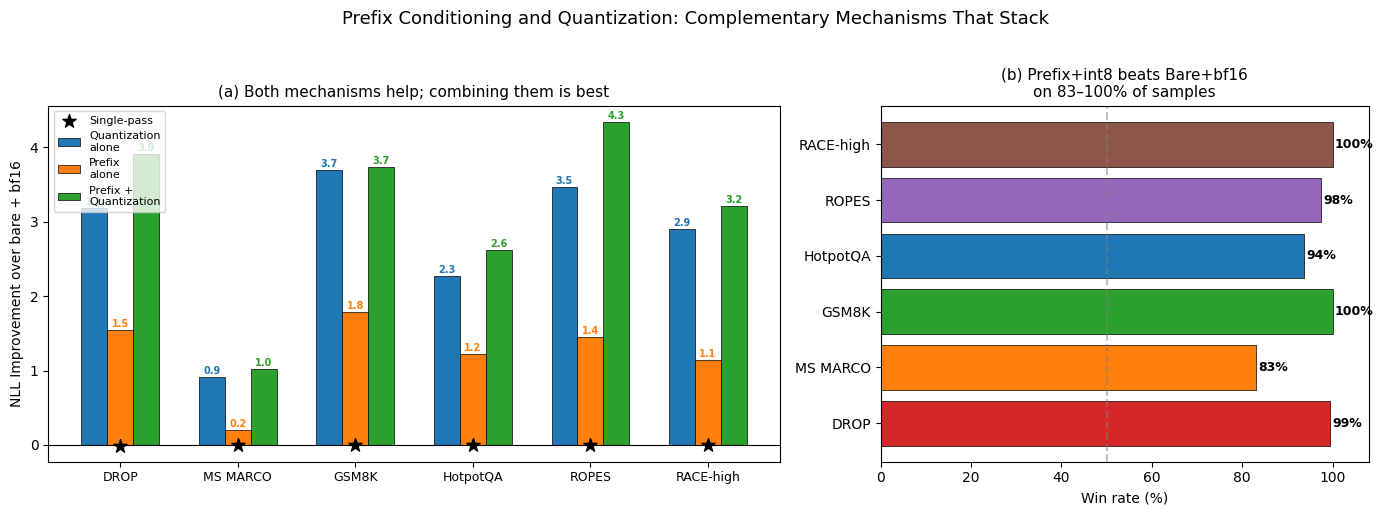

Saved: ../../../results/decoder_only/exp08/charts/fig5_prefix_quantization_interaction.png


In [6]:
# Cell 7: Figure 5 — Prefix + quantization: partial overlap, strong combination
# Panel A: NLL improvement over bare+bf16 baseline for each configuration
# Panel B: Win rate of prefix+int8 vs bare+bf16

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [3, 2]})

# Reference: bare+bf16 is the baseline (0 improvement)
configs = [
    ('bare', 'int8', 'Quantization\nalone', '#1f77b4'),
    ('comprehend_64', 'bf16', 'Prefix\nalone', '#ff7f0e'),
    ('comprehend_64', 'int8', 'Prefix +\nQuantization', '#2ca02c'),
]

# --- Panel A: Improvement over bare+bf16 ---
ax = axes[0]
x = np.arange(len(available_ds))
width = 0.22

for j, (cond, pert, label, color) in enumerate(configs):
    imps = [(nll_arrays[ds][('bare', 'bf16')] - nll_arrays[ds][(cond, pert)]).mean()
            for ds in available_ds]
    offset = (j - len(configs) / 2 + 0.5) * width
    bars = ax.bar(x + offset, imps, width, label=label,
                  color=color, edgecolor='black', linewidth=0.5)
    # Value labels
    for i, imp in enumerate(imps):
        ax.text(i + offset, imp + 0.04, f"{imp:.1f}",
                ha='center', fontsize=7, fontweight='bold', color=color)

# Single-pass improvement reference
sp_imps = [(nll_arrays[ds][('bare', 'bf16')] - nll_arrays[ds]['single_pass']).mean()
           for ds in available_ds]
ax.scatter(x, sp_imps, marker='*', s=100, color='black', zorder=5, label='Single-pass')

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([DS_LABELS[ds] for ds in available_ds], fontsize=9)
ax.set_ylabel('NLL Improvement over bare + bf16', fontsize=10)
ax.set_title('(a) Both mechanisms help; combining them is best', fontsize=11)
ax.legend(fontsize=8, loc='upper left')

# --- Panel B: Win rate of prefix+int8 vs bare+bf16 ---
ax = axes[1]
win_rates = []
for ds in available_ds:
    comp_int8 = nll_arrays[ds][('comprehend_64', 'int8')]
    bare_bf16 = nll_arrays[ds][('bare', 'bf16')]
    win_rates.append(np.mean(comp_int8 < bare_bf16) * 100)

bars = ax.barh(range(len(available_ds)), win_rates,
               color=[DS_COLORS[ds] for ds in available_ds],
               edgecolor='black', linewidth=0.5)

for i, wr in enumerate(win_rates):
    ax.text(wr + 0.5, i, f"{wr:.0f}%", va='center', fontsize=9, fontweight='bold')

ax.axvline(x=50, color='gray', linestyle='--', alpha=0.5)
ax.set_yticks(range(len(available_ds)))
ax.set_yticklabels([DS_LABELS[ds] for ds in available_ds], fontsize=10)
ax.set_xlabel('Win rate (%)', fontsize=10)
ax.set_title('(b) Prefix+int8 beats Bare+bf16\non 83\u2013100% of samples', fontsize=11)
ax.set_xlim(0, 108)

plt.suptitle('Prefix Conditioning and Quantization: Complementary Mechanisms That Stack',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'fig5_prefix_quantization_interaction.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {CHARTS_DIR / 'fig5_prefix_quantization_interaction.png'}")


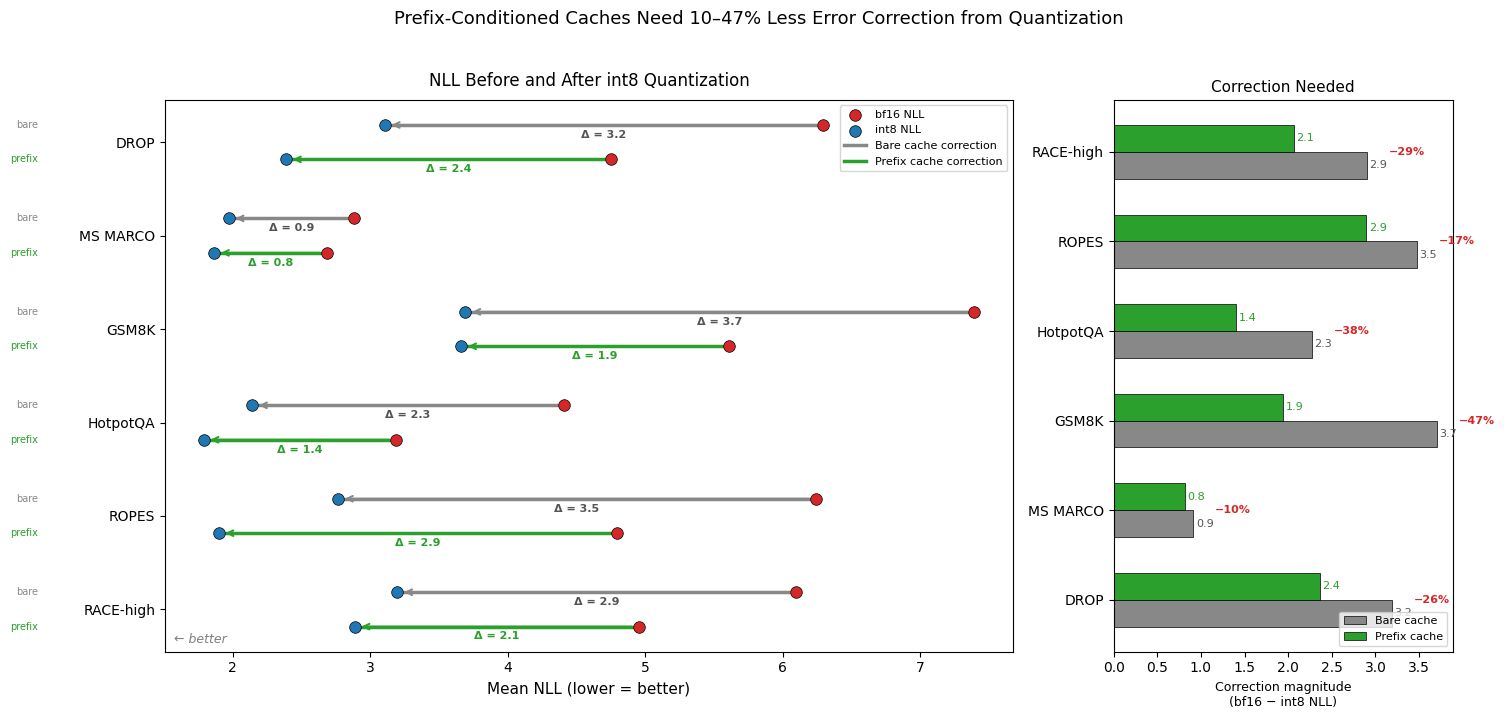

Saved: ../../../results/decoder_only/exp08/charts/fig8_prefix_shielding.png


In [7]:
# Cell 8: Figure 8 — How much error correction does quantization provide?
#
# Dumbbell chart: for each dataset, show the NLL BEFORE and AFTER int8 quantization,
# connected by an arrow. The arrow length IS the correction needed.
# Two rows per dataset: bare (gray) and prefix (green).
# Immediately visible: gray arrows are long (lots of correction), green arrows are short.
#
# Right panel: direct comparison of correction magnitude.

fig, axes = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={'width_ratios': [3, 1.2]})

# --- Panel A: Dumbbell chart ---
ax = axes[0]

y_positions = []
y_labels = []
row = 0
spacing = 0.6   # gap between datasets
pair_gap = 0.35  # gap between bare and prefix within a dataset

bare_corrections = []
prefix_corrections = []

for i, ds in enumerate(available_ds):
    bare_bf16 = nll_arrays[ds][('bare', 'bf16')].mean()
    bare_int8 = nll_arrays[ds][('bare', 'int8')].mean()
    pref_bf16 = nll_arrays[ds][('comprehend_64', 'bf16')].mean()
    pref_int8 = nll_arrays[ds][('comprehend_64', 'int8')].mean()

    y_bare = row
    y_pref = row + pair_gap

    # Bare: bf16 dot → int8 dot with arrow
    ax.plot([bare_bf16, bare_int8], [y_bare, y_bare], color='#888888', linewidth=2.5, zorder=1)
    ax.scatter([bare_bf16], [y_bare], color='#d62728', s=70, zorder=3, edgecolors='black', linewidths=0.5)
    ax.scatter([bare_int8], [y_bare], color='#1f77b4', s=70, zorder=3, edgecolors='black', linewidths=0.5)
    correction_bare = bare_bf16 - bare_int8
    ax.annotate('', xy=(bare_int8 + 0.03, y_bare), xytext=(bare_bf16 - 0.03, y_bare),
                arrowprops=dict(arrowstyle='->', color='#888888', lw=1.5))
    ax.text((bare_bf16 + bare_int8) / 2, y_bare + 0.13,
            f"\u0394 = {correction_bare:.1f}", ha='center', fontsize=8,
            color='#555555', fontweight='bold')

    # Prefix: bf16 dot → int8 dot with arrow
    ax.plot([pref_bf16, pref_int8], [y_pref, y_pref], color='#2ca02c', linewidth=2.5, zorder=1)
    ax.scatter([pref_bf16], [y_pref], color='#d62728', s=70, zorder=3, edgecolors='black', linewidths=0.5)
    ax.scatter([pref_int8], [y_pref], color='#1f77b4', s=70, zorder=3, edgecolors='black', linewidths=0.5)
    correction_pref = pref_bf16 - pref_int8
    ax.annotate('', xy=(pref_int8 + 0.03, y_pref), xytext=(pref_bf16 - 0.03, y_pref),
                arrowprops=dict(arrowstyle='->', color='#2ca02c', lw=1.5))
    ax.text((pref_bf16 + pref_int8) / 2, y_pref + 0.13,
            f"\u0394 = {correction_pref:.1f}", ha='center', fontsize=8,
            color='#2ca02c', fontweight='bold')

    bare_corrections.append(correction_bare)
    prefix_corrections.append(correction_pref)

    # Dataset label on the left
    y_mid = (y_bare + y_pref) / 2
    y_positions.append(y_mid)
    y_labels.append(DS_LABELS[ds])

    # Conditioning labels
    ax.text(-0.15, y_bare, 'bare', ha='right', va='center', fontsize=7, color='#888888',
            transform=ax.get_yaxis_transform())
    ax.text(-0.15, y_pref, 'prefix', ha='right', va='center', fontsize=7, color='#2ca02c',
            transform=ax.get_yaxis_transform())

    row += pair_gap + spacing

# Legend dots
ax.scatter([], [], color='#d62728', s=70, edgecolors='black', linewidths=0.5, label='bf16 NLL')
ax.scatter([], [], color='#1f77b4', s=70, edgecolors='black', linewidths=0.5, label='int8 NLL')
ax.plot([], [], color='#888888', linewidth=2.5, label='Bare cache correction')
ax.plot([], [], color='#2ca02c', linewidth=2.5, label='Prefix cache correction')

ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels, fontsize=10)
ax.set_xlabel('Mean NLL (lower = better)', fontsize=11)
ax.set_title('NLL Before and After int8 Quantization', fontsize=12, pad=10)
ax.legend(fontsize=8, loc='upper right')
ax.invert_yaxis()

# Light shading to show "better" direction
ax.text(0.01, 0.01, '\u2190 better', transform=ax.transAxes,
        fontsize=9, color='gray', style='italic', va='bottom')

# --- Panel B: Correction magnitude comparison ---
ax = axes[1]

y_pos = np.arange(len(available_ds))
height = 0.3

ax.barh(y_pos - height/2, bare_corrections, height, label='Bare cache',
        color='#888888', edgecolor='black', linewidth=0.5)
ax.barh(y_pos + height/2, prefix_corrections, height, label='Prefix cache',
        color='#2ca02c', edgecolor='black', linewidth=0.5)

# Value labels and reduction %
for i in range(len(available_ds)):
    ax.text(bare_corrections[i] + 0.03, i - height/2,
            f"{bare_corrections[i]:.1f}", va='center', fontsize=8, color='#555555')
    ax.text(prefix_corrections[i] + 0.03, i + height/2,
            f"{prefix_corrections[i]:.1f}", va='center', fontsize=8, color='#2ca02c')
    # Reduction percentage
    if bare_corrections[i] > 0:
        reduction = (1 - prefix_corrections[i] / bare_corrections[i]) * 100
        ax.text(max(bare_corrections[i], prefix_corrections[i]) + 0.25, i,
                f"\u2212{reduction:.0f}%",
                va='center', fontsize=8, color='#d62728', fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels([DS_LABELS[ds] for ds in available_ds], fontsize=10)
ax.set_xlabel('Correction magnitude\n(bf16 \u2212 int8 NLL)', fontsize=9)
ax.set_title('Correction Needed', fontsize=11)
ax.legend(fontsize=8, loc='lower right')

plt.suptitle('Prefix-Conditioned Caches Need 10\u201347% Less Error Correction from Quantization',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'fig8_prefix_shielding.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {CHARTS_DIR / 'fig8_prefix_shielding.png'}")


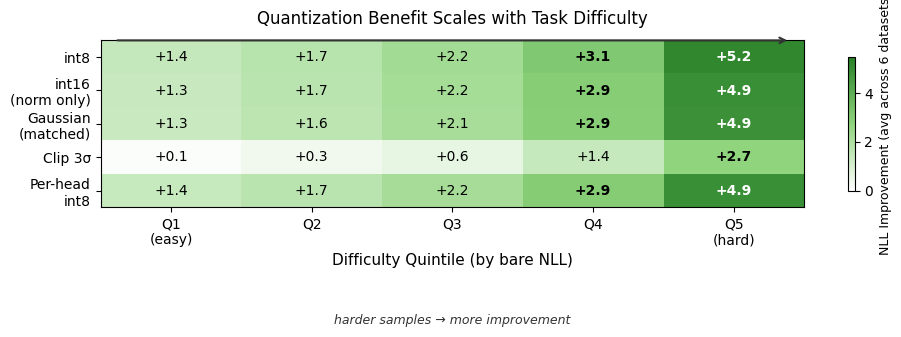

Saved: ../../../results/decoder_only/exp08/charts/fig6_hardness_gradient.png


In [8]:
# Cell 8: Figure 6 — Benefit increases with task difficulty
# Heatmap: NLL improvement (positive = better) by quintile, averaged across 6 datasets.
# Uses sequential green colormap (darker = more improvement).

key_perts = ['int8', 'int16', 'gaussian_matched', 'clip_3sigma', 'per_channel_int8']
key_labels = ['int8', 'int16\n(norm only)', 'Gaussian\n(matched)', 'Clip 3\u03c3', 'Per-head\nint8']
Q_LABELS = ['Q1\n(easy)', 'Q2', 'Q3', 'Q4', 'Q5\n(hard)']

# Aggregate NLL improvement across all datasets (positive = better)
n_pert = len(key_perts)
n_q = 5
heatmap = np.zeros((n_pert, n_q))
count_map = np.zeros((n_pert, n_q))

for ds in available_ds:
    results = per_sample[ds]
    bf16_bare = np.array([r['nll_bare_bf16'] for r in results])
    quintile_bounds = np.percentile(bf16_bare, [20, 40, 60, 80])
    quintiles = np.digitize(bf16_bare, quintile_bounds)

    for pi, pert in enumerate(key_perts):
        pert_arr = np.array([r[f'nll_bare_{pert}'] for r in results])
        for q in range(5):
            mask = quintiles == q
            if mask.sum() > 2:
                improvement = (bf16_bare[mask] - pert_arr[mask]).mean()  # positive = better
                heatmap[pi, q] += improvement
                count_map[pi, q] += 1

heatmap = np.where(count_map > 0, heatmap / count_map, 0)

fig, ax = plt.subplots(figsize=(10, 5))

# Sequential green colormap (white to dark green)
cmap = LinearSegmentedColormap.from_list('improvement',
    [(1, 1, 1), (0.56, 0.83, 0.49), (0.15, 0.5, 0.15)])

vmax = heatmap.max() * 1.05
im = ax.imshow(heatmap, cmap=cmap, aspect='auto', vmin=0, vmax=vmax)

# Text annotations
for i in range(n_pert):
    for j in range(n_q):
        val = heatmap[i, j]
        color = 'white' if val > vmax * 0.6 else 'black'
        ax.text(j, i, f"+{val:.1f}", ha='center', va='center',
                fontsize=10, fontweight='bold' if val > 2.5 else 'normal',
                color=color)

# Arrow annotation showing gradient direction
ax.annotate('', xy=(4.4, -0.5), xytext=(-0.4, -0.5),
            arrowprops=dict(arrowstyle='->', color='#333333', lw=1.5),
            annotation_clip=False)
ax.text(2, -0.7, 'harder samples \u2192 more improvement', ha='center',
        fontsize=9, color='#333333', style='italic',
        transform=ax.get_xaxis_transform())

ax.set_xticks(range(n_q))
ax.set_xticklabels(Q_LABELS, fontsize=10)
ax.set_yticks(range(n_pert))
ax.set_yticklabels(key_labels, fontsize=10)
ax.set_xlabel('Difficulty Quintile (by bare NLL)', fontsize=11)

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('NLL Improvement (avg across 6 datasets)', fontsize=9)

ax.set_title('Quantization Benefit Scales with Task Difficulty', fontsize=12, pad=12)

plt.tight_layout()
plt.savefig(CHARTS_DIR / 'fig6_hardness_gradient.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {CHARTS_DIR / 'fig6_hardness_gradient.png'}")


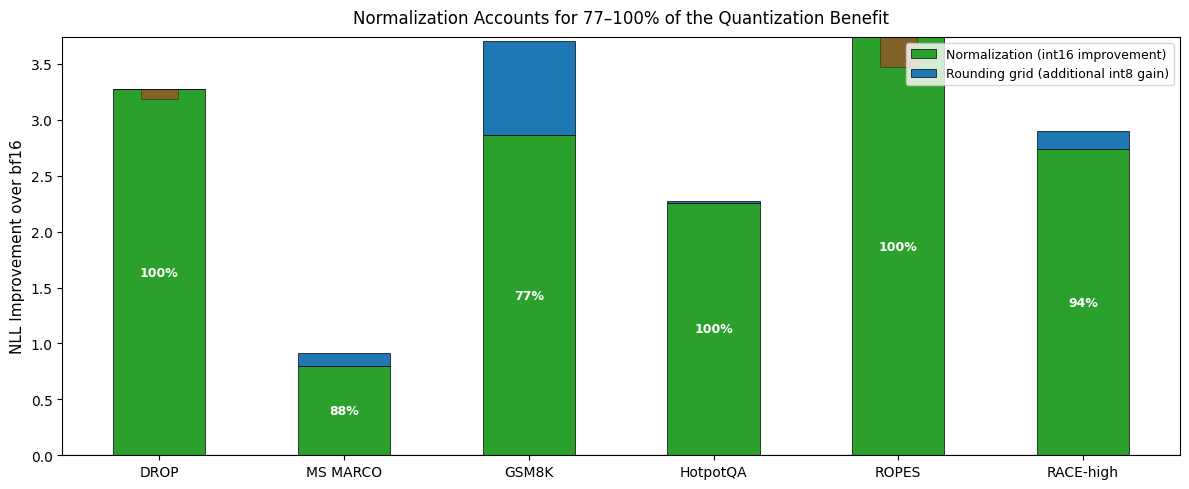

Saved: ../../../results/decoder_only/exp08/charts/fig7_mechanism_decomposition.png


In [9]:
# Cell 9: Figure 7 — Mechanism decomposition: normalization vs rounding
# Stacked bars showing how much of the int8 improvement comes from each component.

fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(available_ds))
width = 0.5

norm_imp = []      # int16 improvement (normalization alone)
rounding_imp = []  # additional improvement from int8 rounding grid

for ds in available_ds:
    bf16 = nll_arrays[ds][('bare', 'bf16')]
    int16_improvement = (bf16 - nll_arrays[ds][('bare', 'int16')]).mean()
    int8_improvement = (bf16 - nll_arrays[ds][('bare', 'int8')]).mean()
    norm_imp.append(int16_improvement)
    rounding_imp.append(int8_improvement - int16_improvement)  # can be negative

# Split rounding into positive contribution and "rounding hurts" portion
round_pos = [max(r, 0) for r in rounding_imp]
round_neg = [max(-r, 0) for r in rounding_imp]

bars1 = ax.bar(x, norm_imp, width, label='Normalization (int16 improvement)',
               color='#2ca02c', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, round_pos, width, bottom=norm_imp,
               label='Rounding grid (additional int8 gain)',
               color='#1f77b4', edgecolor='black', linewidth=0.5)

# If rounding hurts, show as a red bar descending from int16
for i in range(len(available_ds)):
    if round_neg[i] > 0.01:
        ax.bar(x[i], -round_neg[i], width * 0.4, bottom=norm_imp[i],
               color='#d62728', edgecolor='black', linewidth=0.5, alpha=0.5)

# Percentage labels (inside the normalization bar to avoid title collision)
for i in range(len(available_ds)):
    total = norm_imp[i] + round_pos[i]
    if total > 0:
        pct = norm_imp[i] / total * 100
        label = f"{pct:.0f}%" if pct <= 100 else ">100%"
        ax.text(i, norm_imp[i] * 0.5, label,
                ha='center', va='center', fontsize=9, color='white', fontweight='bold')

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([DS_LABELS[ds] for ds in available_ds], fontsize=10)
ax.set_ylabel('NLL Improvement over bf16', fontsize=11)
ax.set_title('Normalization Accounts for 77\u2013100% of the Quantization Benefit',
             fontsize=12, pad=10)
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig(CHARTS_DIR / 'fig7_mechanism_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {CHARTS_DIR / 'fig7_mechanism_decomposition.png'}")


In [10]:
# Cell 10: Summary
print("=" * 70)
print("ALL CHARTS GENERATED")
print("=" * 70)

for f in sorted(CHARTS_DIR.iterdir()):
    if f.suffix == '.png':
        size_kb = f.stat().st_size / 1024
        print(f"  {f.name}: {size_kb:.0f} KB")

print(f"\nCharts saved to: {CHARTS_DIR}")
print("Done!")


ALL CHARTS GENERATED
  fig1_cross_dataset_delta_nll.png: 67 KB
  fig1_nll_improvement_by_perturbation.png: 81 KB
  fig2_hypothesis_heatmap.png: 103 KB
  fig2_hypothesis_verdict.png: 117 KB
  fig3_normalization_mechanism.png: 111 KB
  fig4_k_vs_v_decomposition.png: 74 KB
  fig5_prefix_quantization_interaction.png: 118 KB
  fig6_hardness_gradient.png: 76 KB
  fig7_mechanism_decomposition.png: 64 KB
  fig8_prefix_shielding.png: 159 KB

Charts saved to: ../../../results/decoder_only/exp08/charts
Done!
